# Exploratory Data Analysis (EDA) - KCropAI
**Datasets:** Crop Recommendation (Classification) & Kerala Crop Yield (Regression)

In this notebook, we perform EDA on two datasets to fulfill our project objectives:
1. **Classification Analysis:** Understanding how soil and weather parameters affect crop selection.
2. **Regression Analysis (Kerala Context):** Analyzing historical crop yields in local Indian/Kerala environments to handle massive scale variances.

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for plots
sns.set_theme(style="whitegrid", palette="muted")

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Import Success")

Import Success


### 1. Classification Data: Loading and Basic Inspection
First, we load the `crop_recommendation.csv` dataset, which will power our Machine Learning Classification model.

In [2]:
# Load the classification dataset
df_rec = pd.read_csv('../data/crop_recommendation.csv')

# Display the first 5 rows
display(df_rec.head())

# Check dataset shape and data types
print(f"Dataset Shape: {df_rec.shape}")
print("\nMissing Values:")
print(df_rec.isnull().sum())

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


Dataset Shape: (2200, 8)

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


### 2. Target Variable Distribution
Let's ensure our dataset is balanced across the 22 different crop categories. We use a tall figure size to prevent the crop names from overlapping on the Y-axis.

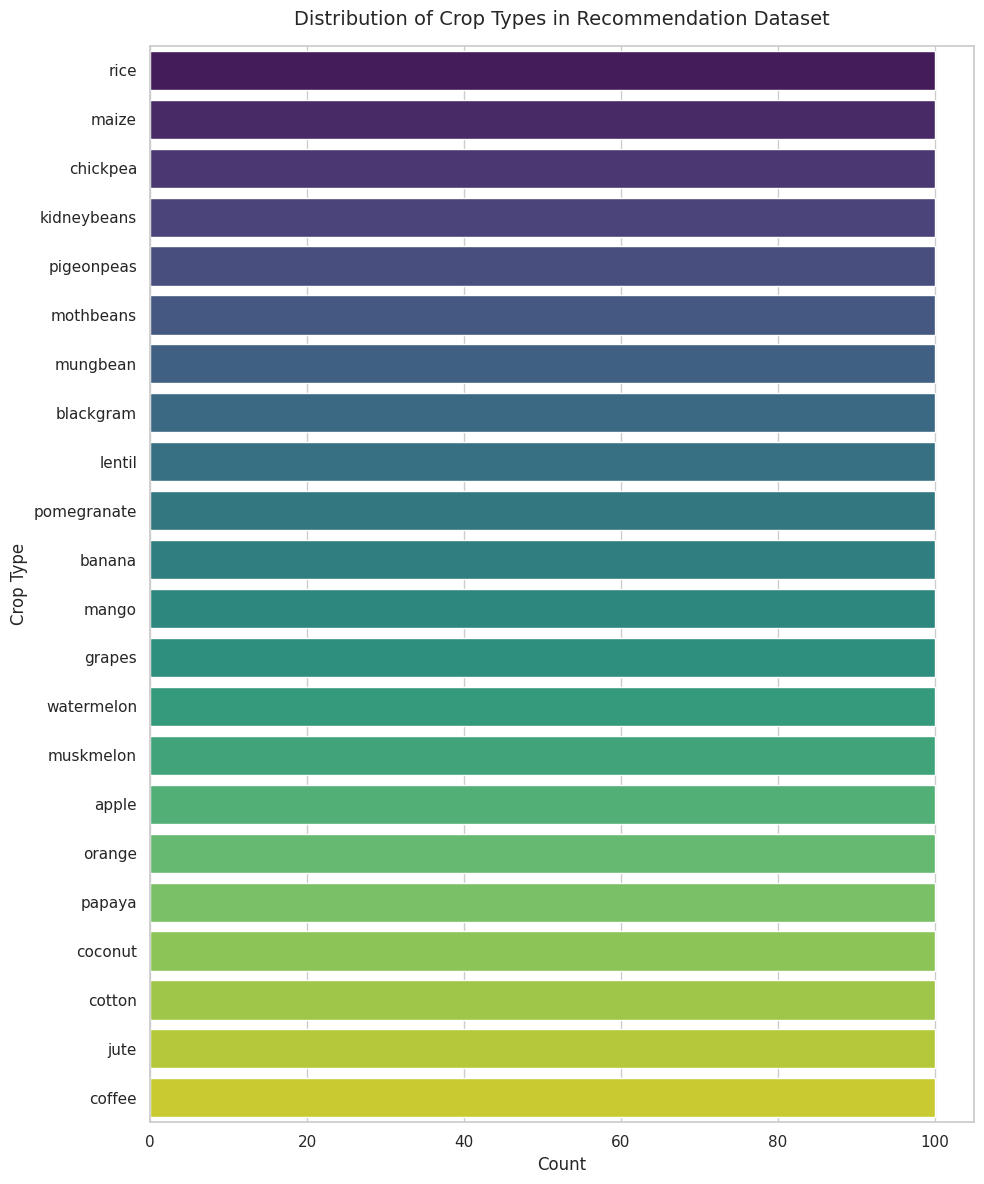

In [3]:
# Set a tall figure size to prevent overlapping text
plt.figure(figsize=(10, 12))

# Create the countplot
sns.countplot(y='label', data=df_rec, order=df_rec['label'].value_counts().index, palette='viridis')

plt.title("Distribution of Crop Types in Recommendation Dataset", fontsize=14, pad=15)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Crop Type", fontsize=12)

# Prevent labels from getting cut off or squished
plt.tight_layout() 
plt.show()

### 3. Kerala Context: Rainfall and pH Analysis
Kerala's agriculture is heavily influenced by abundant rainfall and slightly acidic soils. Let's visualize how these specific features dictate which crop grows best.

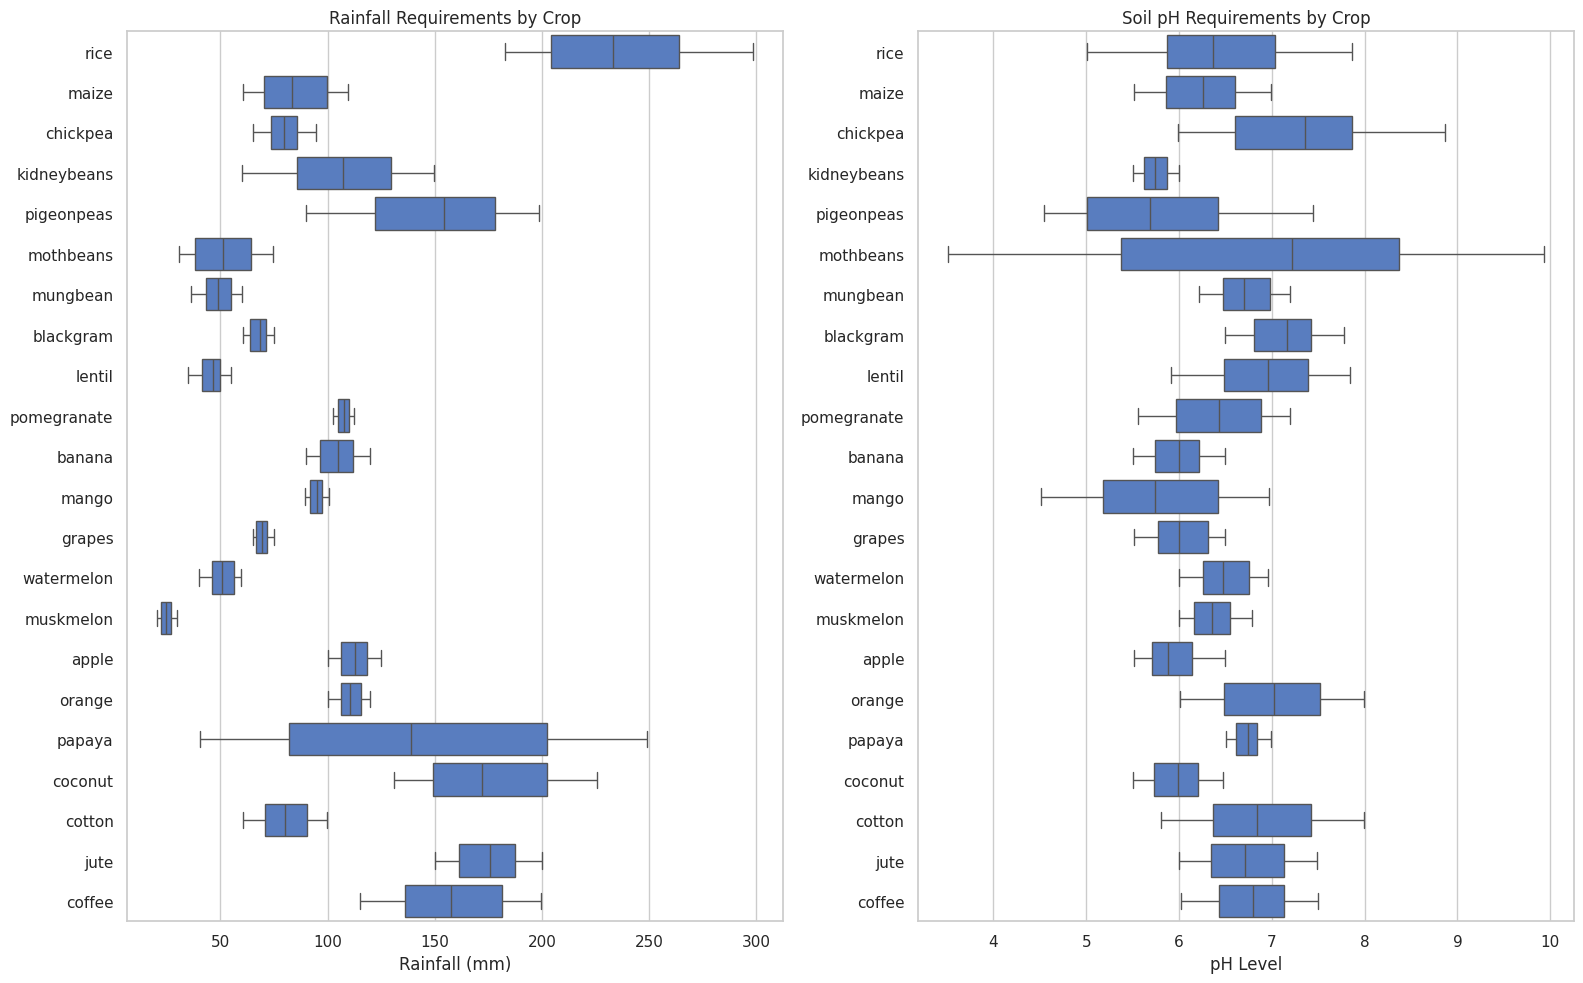

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Rainfall Boxplot
sns.boxplot(x='rainfall', y='label', data=df_rec, ax=axes[0])
axes[0].set_title("Rainfall Requirements by Crop")
axes[0].set_xlabel("Rainfall (mm)")
axes[0].set_ylabel("")

# pH Boxplot
sns.boxplot(x='ph', y='label', data=df_rec, ax=axes[1])
axes[1].set_title("Soil pH Requirements by Crop")
axes[1].set_xlabel("pH Level")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### 4. Feature Correlation
We calculate the correlation between our numerical features to identify highly correlated metrics before feeding them into our Random Forest classifier.

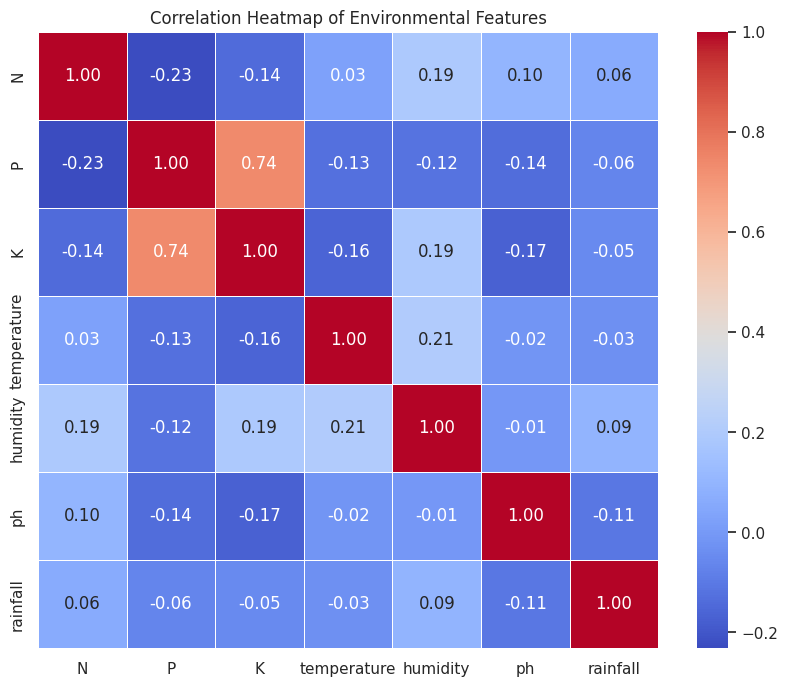

In [5]:
plt.figure(figsize=(10, 8))

# Drop the categorical 'label' column for correlation math
numerical_df = df_rec.drop('label', axis=1)

# Calculate Pearson correlation matrix
corr_matrix = numerical_df.corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Environmental Features")
plt.show()

### 5. Localized Context: Kerala Crop Yield Analysis (Regression Data)
While the classification model recommends *what* to plant, we must also understand historical performance. We analyze `crop_yield_kerala.csv` here. 

**Note on Data Scaling:** Since Coconuts are measured in individual nuts rather than tonnes, their yield numbers are astronomically higher than crops like Rice. We apply a **Logarithmic Scale** to the X-axis to accurately compare these disparate metrics side-by-side.

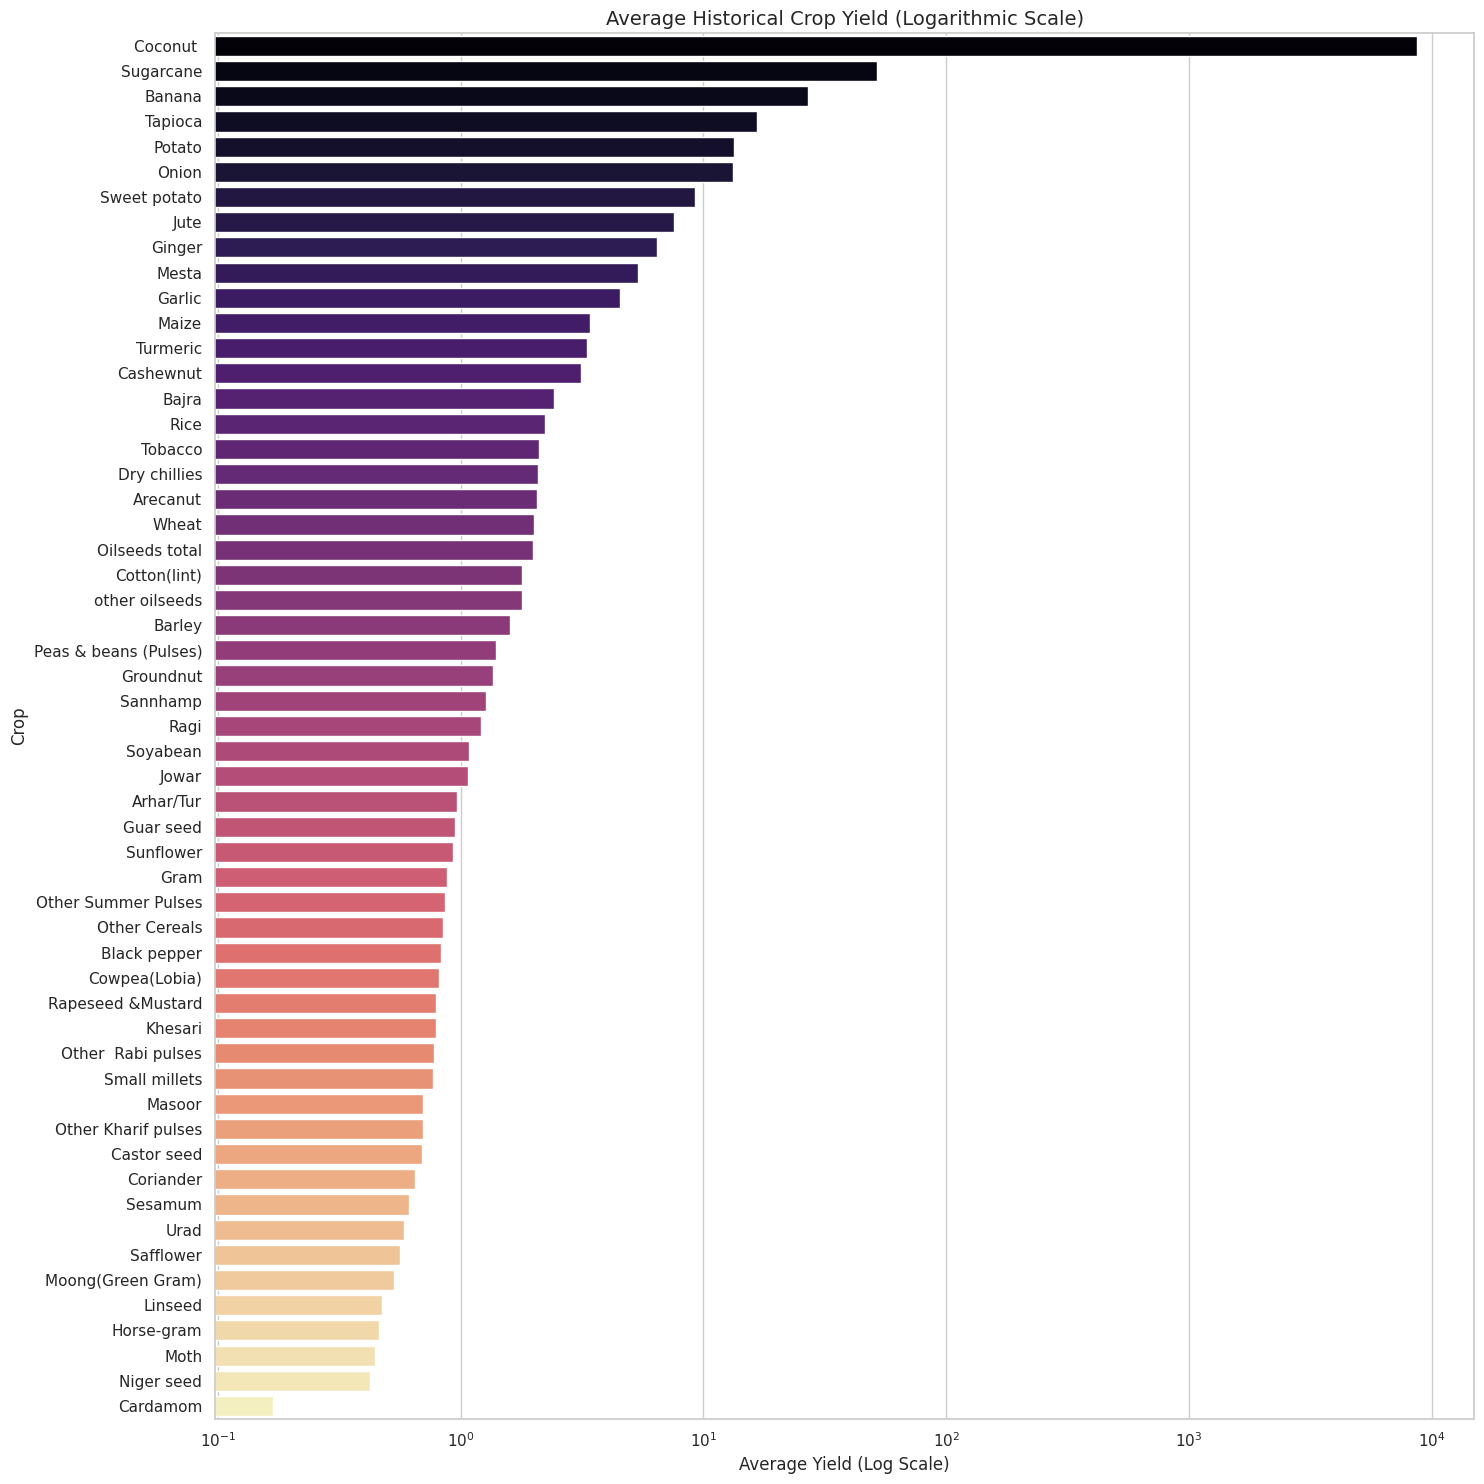


Correlation with Yield:


Yield              1.000000
Annual_Rainfall    0.020761
Fertilizer         0.002862
Pesticide          0.001782
Name: Yield, dtype: float64

In [6]:
# Load the localized yield dataset for our regression model
df_kerala = pd.read_csv('../data/crop_yield_kerala.csv')

# Clean up the dataset by dropping rows with missing production data
df_kerala = df_kerala.dropna(subset=['Yield', 'Crop'])

# Plot Average Yield by Crop
plt.figure(figsize=(15, 15))

# Sorting the values so the chart is easy to read
yield_order = df_kerala.groupby('Crop')['Yield'].mean().sort_values(ascending=False).index

# Plot using a logarithmic scale to fix the massive coconut scaling issue
sns.barplot(x='Yield', y='Crop', data=df_kerala, order=yield_order, palette='magma', errorbar=None)
plt.xscale('log')

plt.title("Average Historical Crop Yield (Logarithmic Scale)", fontsize=14)
plt.xlabel("Average Yield (Log Scale)", fontsize=12)
plt.ylabel("Crop", fontsize=12)

plt.tight_layout()
plt.show()

# Display the correlation between rainfall, fertilizer, and yield
print("\nCorrelation with Yield:")
numerical_kerala = df_kerala[['Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']]
display(numerical_kerala.corr()['Yield'].sort_values(ascending=False))